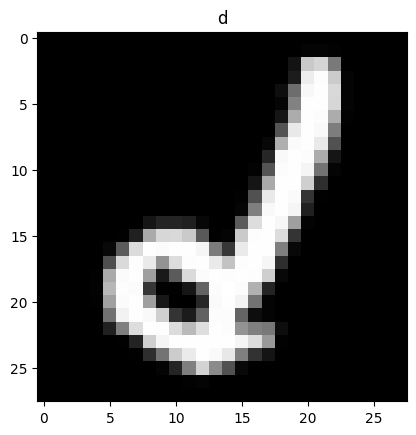

prediction:  X
actual:  d
Epoch 0: 1339.2387681156397


In [ ]:
from pathlib import Path
from torch.utils.data import DataLoader
from datasets.emnist import EMNISTDataset
from utils.label import get_char
from models.cnn import SimpleCNN
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

model_path = Path("../results/simple_cnn.pth")
train_dataset_path = Path("../data/raw/emnist_balenced/emnist-balanced-train.csv")

train_dataset = EMNISTDataset(train_dataset_path)
train_loader = DataLoader( train_dataset, 64, True)

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(get_char(labels[0].item()))
plt.show()

model = SimpleCNN()
if model_path.exists():
    model.load_state_dict(torch.load(model_path))
outputs = model(images)

predictions = outputs.argmax(dim=1)

print("prediction: ",get_char(predictions[0].item()))
print("actual: ",get_char(labels[0].item()))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), 0.001)

best_loss = float("inf")

for epoch in range(5):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if total_loss < best_loss:
        best_loss = total_loss
        torch.save(model.state_dict(), "../results/best_model.pth")
    print(f"Epoch {epoch}: {total_loss}")